# BESS Layout Optimization Engine

This notebook runs the 4-mode layout optimization engine for Battery Energy Storage Systems (BESS).
All heavy lifting, routing, placement loops, and visualization logic have been extracted to `engine.py` and `visualization.py`.

In [1]:
from engine import run_bess_optimization
from visualization import print_comparison, plot_comparison, plot_all_standalone

# =========================================================
# CONFIGURATION
# =========================================================
cable_corridor = [
    (15.4,  0),
    (21.9,  0),
    (47.7,  90.4),
    (31.9,  90.4)
]

out_of_scope = [
    (21.9,  16),
    (53.3,  16),
    (53.3,  90.4),
    (47.7,  90.4)
]

CONFIG = {
    "site_vertices": [
        (0,     0),
        (53.3,  0),
        (53.3,  16),
        (21.9,  16),
        (47.7,  90.4),
        (8,     90.4),
        (0,     90.4),
    ],
    "setback": 0,
    "zones": {
        "non_buildable": [cable_corridor],
        "restricted":    [out_of_scope]
    },
    "equipment": {
        "BESS": {
            "width":     6.06,
            "height":    2.44,
            "clearance": {"front": 2.0, "back": 1.0, "left": 1.0, "right": 1.0}
        },
        "MVS": {
            "width":     6.06,
            "height":    2.44,
            "clearance": {"front": 3.0, "back": 1.5, "left": 1.5, "right": 1.5}
        }
    },
    "max_bess_per_mvs":   4,
    "max_cable_length":   25,
    "mvs_scoring_radius": 25,
    "min_mvs_spacing":    0,
    "grid_resolution":    2.0,
}

In [2]:
import time

scenarios = []
for mode in ("conservative", "aggressive", "ultra_aggressive", "hyper_pack"):
    t0 = time.perf_counter()
    res = run_bess_optimization(CONFIG, mode=mode, verbose=False)
    elapsed = time.perf_counter() - t0
    print(f"{mode:<20s} -> {res['metrics']['bess_count']:3d} BESS in {elapsed:5.1f} s")
    scenarios.append(res)

# Print metrics table
print_comparison(*scenarios)

conservative         ->  31 BESS in  12.7 s
aggressive           ->  35 BESS in  13.4 s
ultra_aggressive     ->  36 BESS in  13.0 s
hyper_pack           ->  40 BESS in 139.2 s

────────────────────────────────────────────────────────────────────────────────────────────────────
Metric              Conservative        Aggressive          Ultra-Aggressive    Hyper-Pack          
────────────────────────────────────────────────────────────────────────────────────────────────────
MVS Count           9                   10                  9                   10                  
BESS Count          31                  35                  36                  40                  
Fully Sat. MVS      6 / 9               6 / 10              9 / 9               10 / 10             
Total Cable (m)     304.7               283.0               322.1               365.0               
Avg Cable (m)       9.8                 8.1                 8.9                 9.1                 
Max Cable (m)  

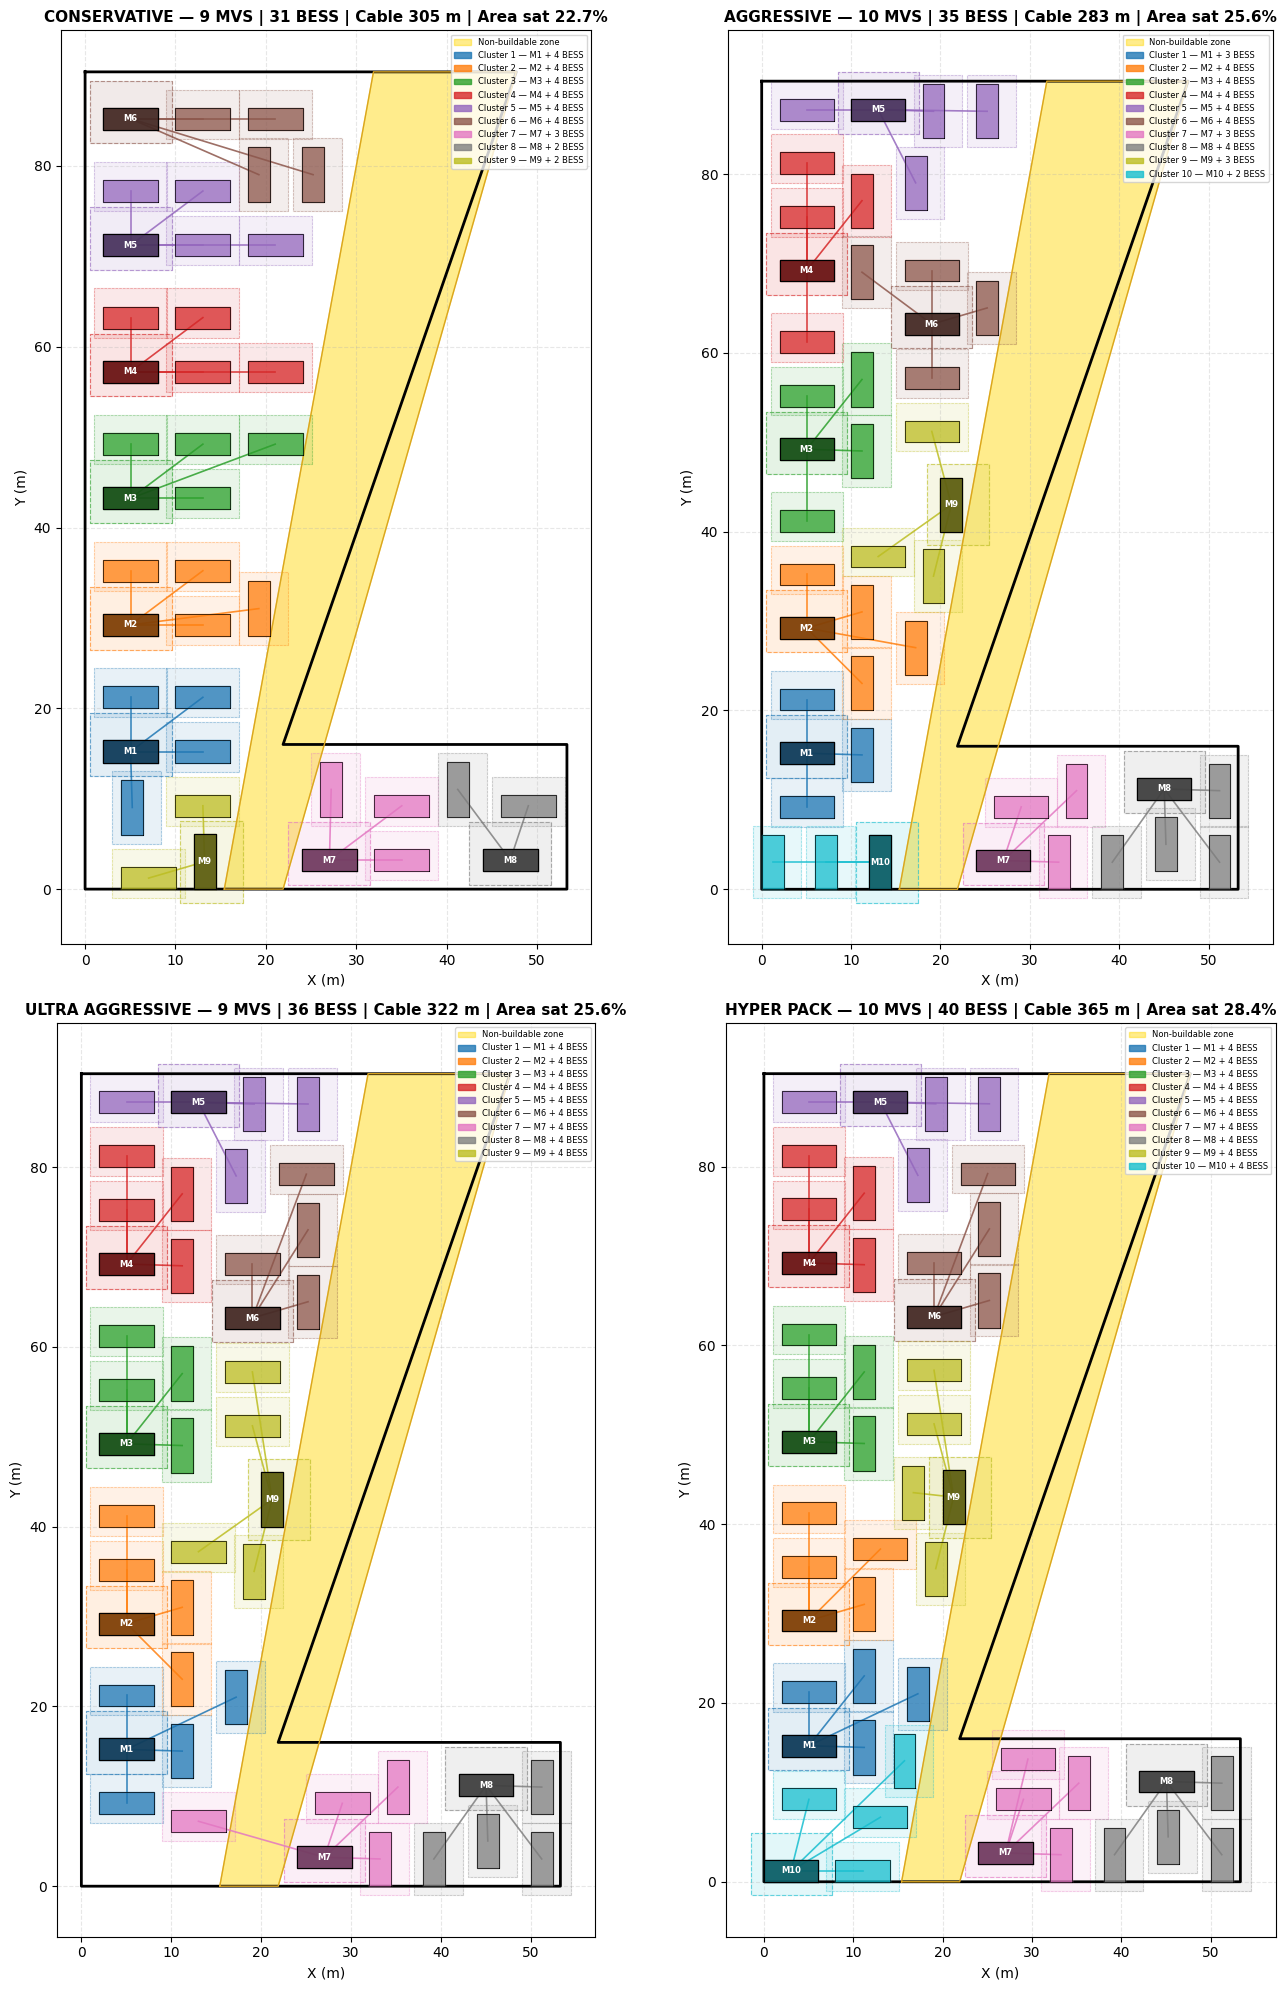

In [3]:
# 2x2 panel overview
plot_comparison(*scenarios, config=CONFIG)

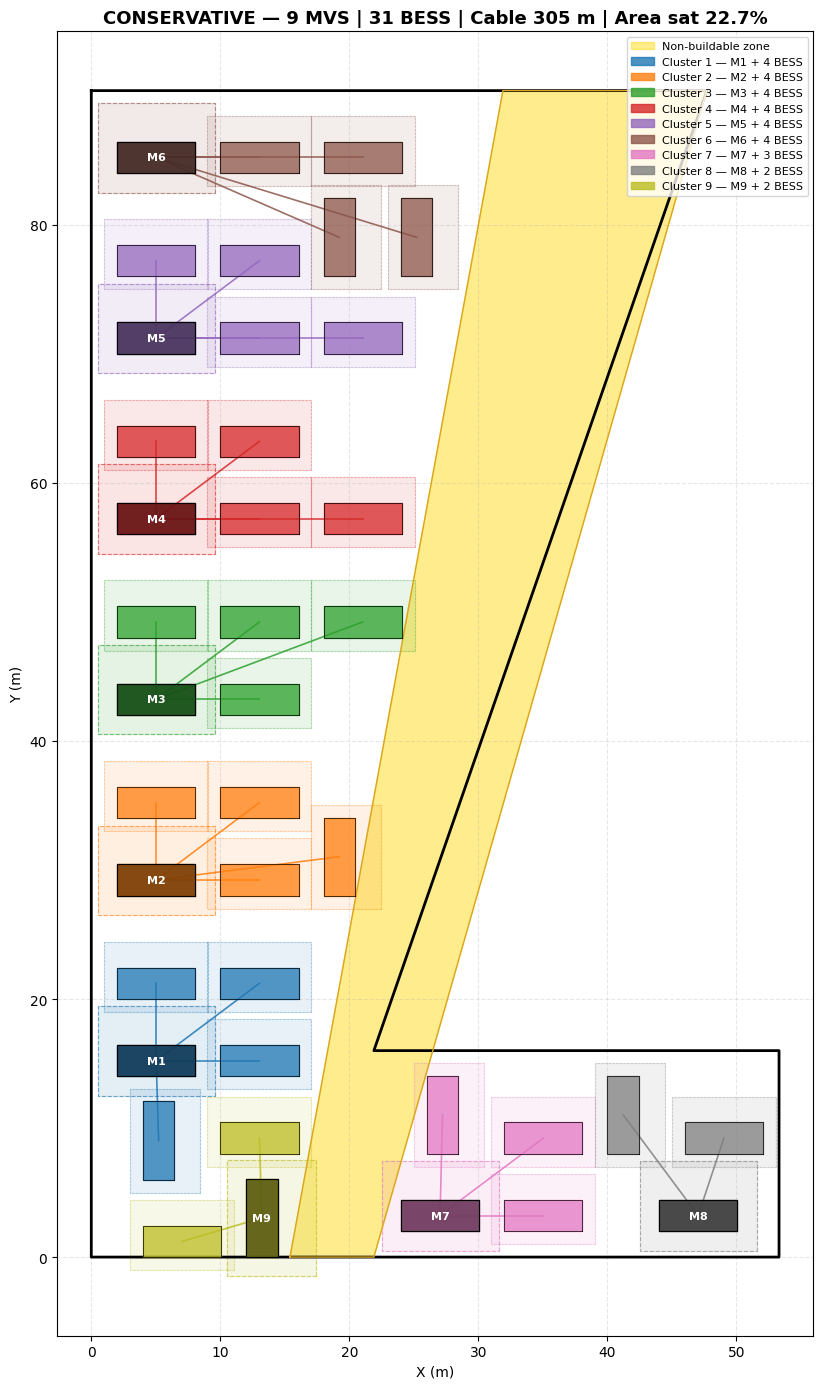

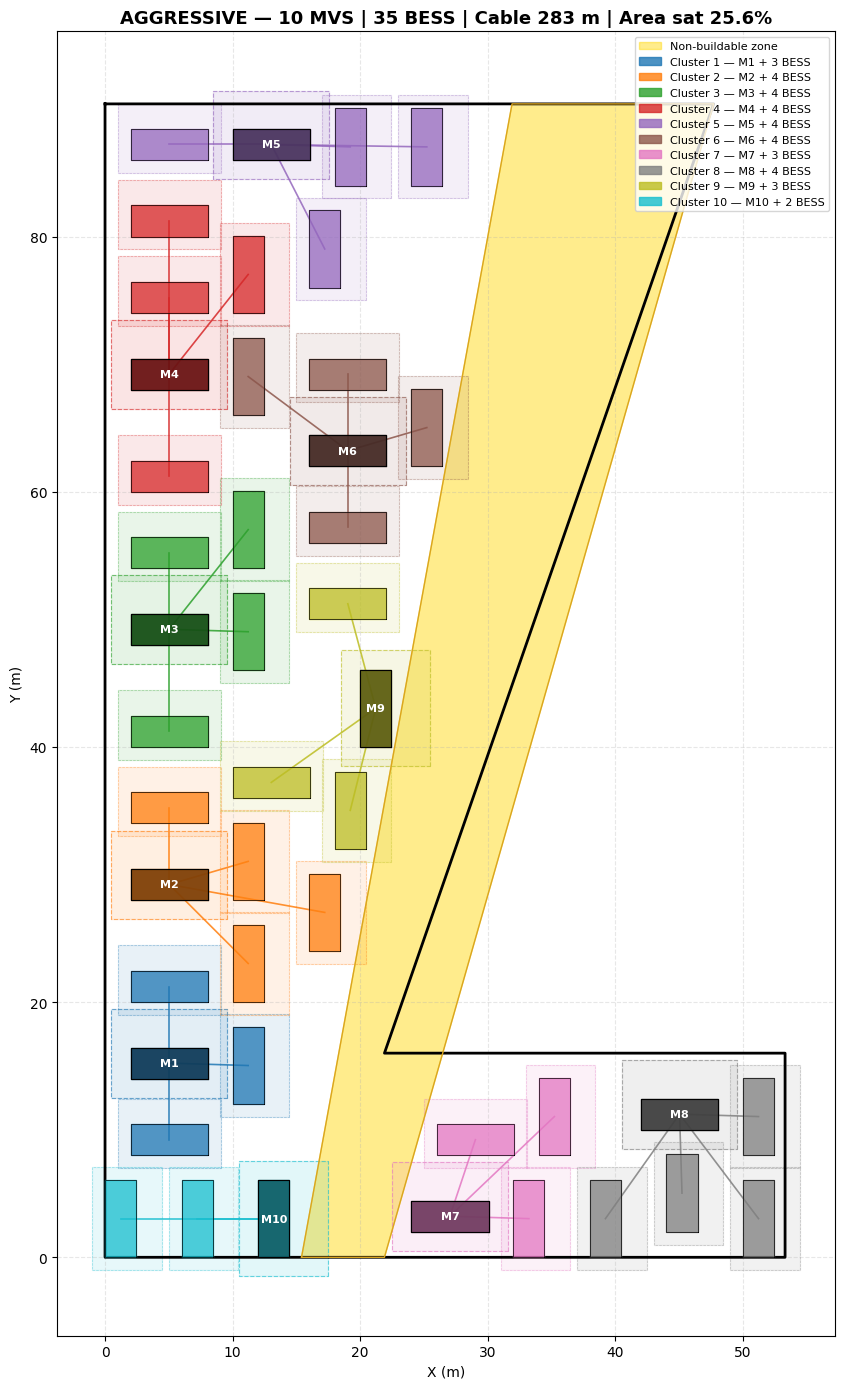

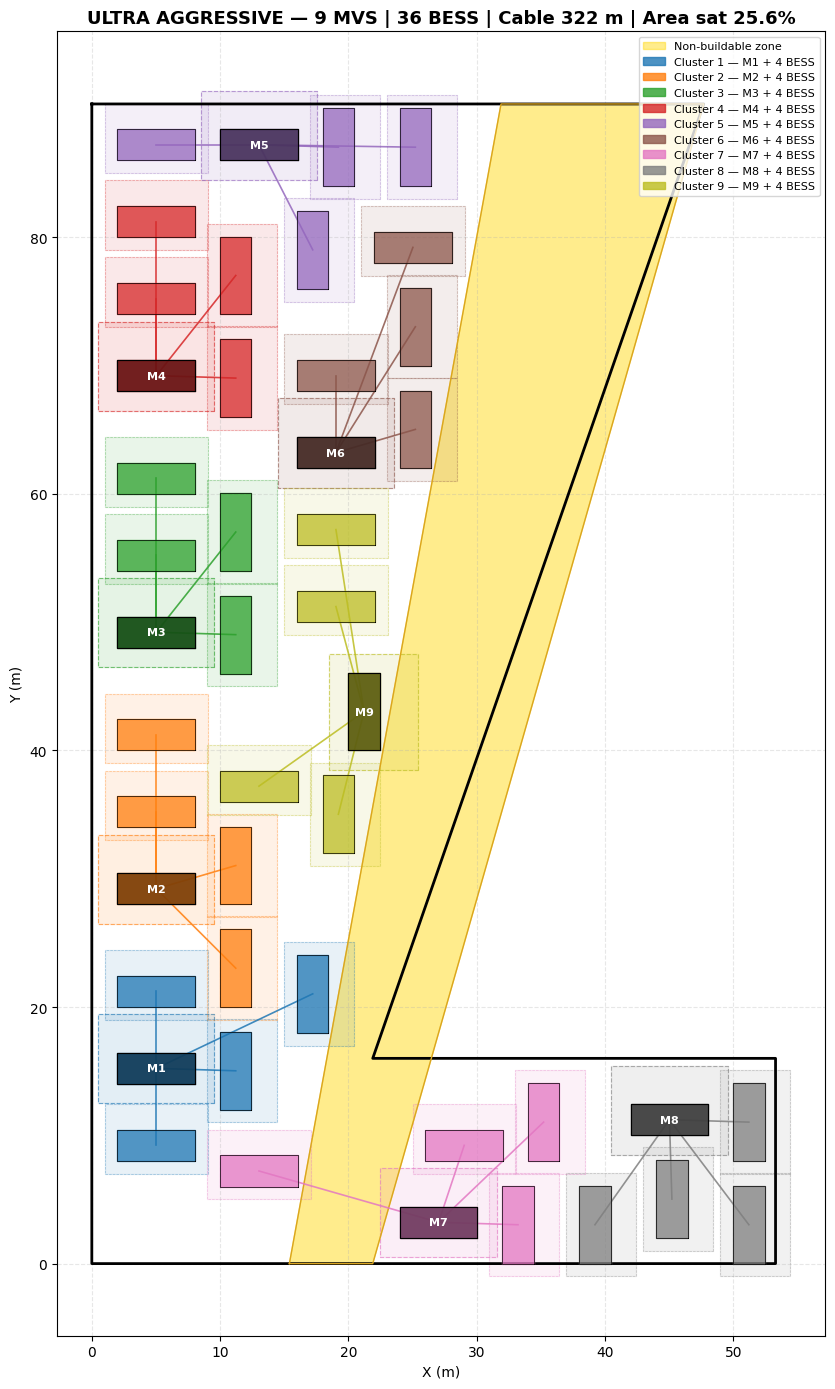

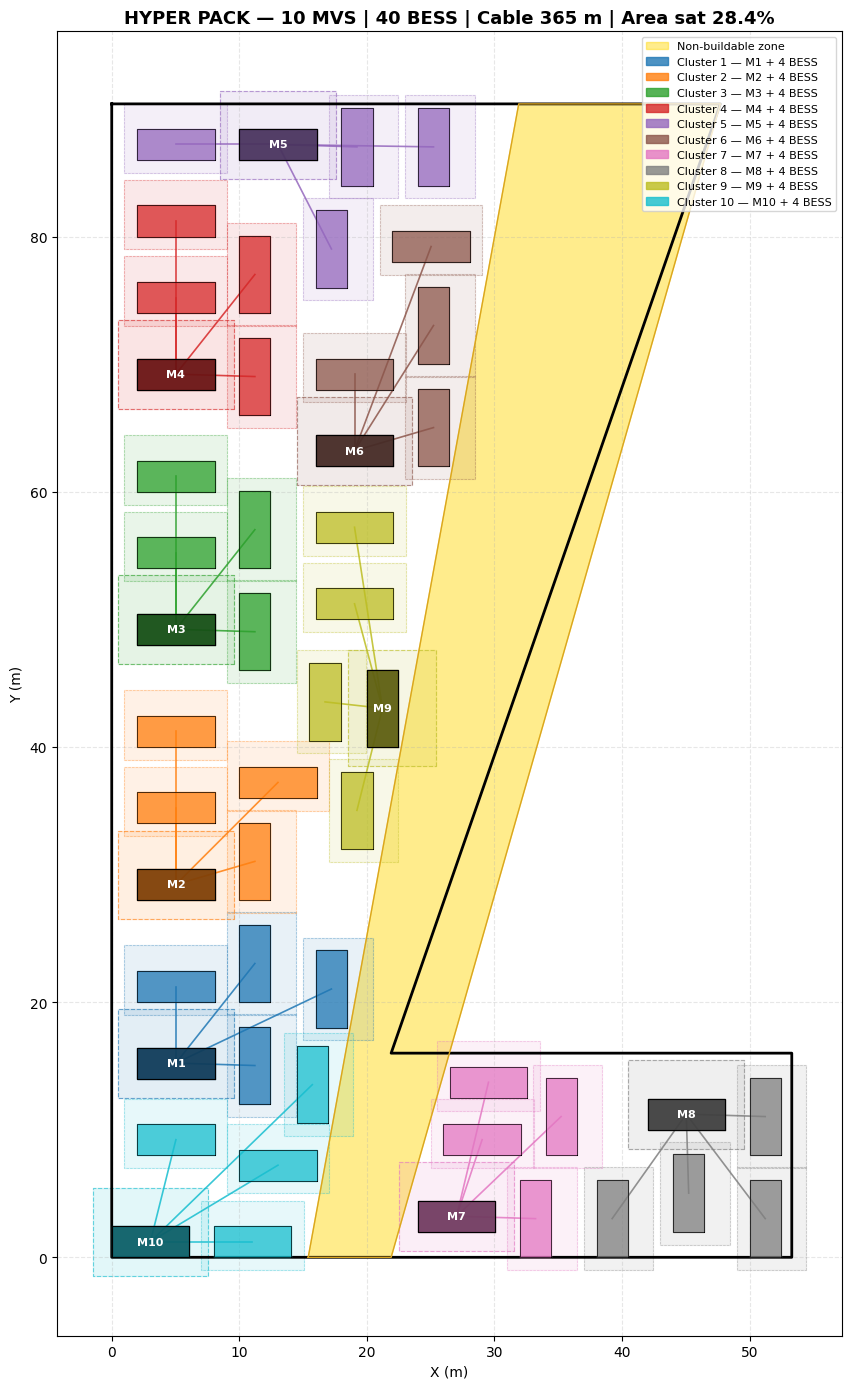

In [4]:
# Full-size standalone figures
plot_all_standalone(*scenarios, config=CONFIG)